<a href="https://colab.research.google.com/github/j5675293/DESAFIOS__NPL_1/blob/NPL_1/DESAFIO_3_ajuste_PNL__I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO 3
## CARRERA DE ESPECIALIDAD EN INTELIGENCIA ARTIFICIAL - FIUBA
### MG. LIC. JUAN RUIZ OTONDO
#### a1702

### Consigna
- Seleccionar un corpus de texto sobre el cual entrenar el modelo de lenguaje.
- Realizar el pre-procesamiento adecuado para tokenizar el corpus, estructurar el dataset y separar entre datos de entrenamiento y validación.
- Proponer arquitecturas de redes neuronales basadas en unidades recurrentes para implementar un modelo de lenguaje.
- Con el o los modelos que consideren adecuados, generar nuevas secuencias a partir de secuencias de contexto con las estrategias de greedy search y beam search determístico y estocástico. En este último caso observar el efecto de la temperatura en la generación de secuencias.
### Sugerencias
- Durante el entrenamiento, guiarse por el descenso de la perplejidad en los datos de validación para finalizar el entrenamiento. Para ello se provee un callback.
- Explorar utilizar SimpleRNN (celda de Elman), LSTM y GRU.
- rmsprop es el optimizador recomendado para la buena convergencia. No obstante se pueden explorar otros.

In [1]:
!pip install tensorflow
!||pip install plotly
!pip install cufflinks

/bin/bash: -c: line 1: syntax error near unexpected token `||'
/bin/bash: -c: line 1: `||pip install plotly'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.6 MB/s eta 0:00:00


In [2]:
from __future__ import print_function
import tensorflow as tf
tf.config.run_functions_eagerly(True)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
from tensorflow.keras.datasets import imdb

#from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [3]:
#si usamos colab
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


## Sobre Dataset
- El Corpus TASS-2020 es un conjunto de datos en español diseñado para tareas de análisis de sentimientos y análisis semántico, especialmente en el contexto de redes sociales.
- tiles para tareas de procesamiento del lenguaje natural. En la edición 2020, se propusieron varios subretos, como:
- Clasificación de sentimientos a nivel global del tweet
- Detección de aspectos y polaridad asociada
- Análisis de emociones
Está pensado para fomentar la investigación en español, un idioma que históricamente ha tenido menos recursos que el inglés en este campo.




In [4]:
import pandas as pd
import numpy as np
import nltk
nltk.download('punkt_tab')
import matplotlib.pyplot as plt

print('Cargando datos...')
# /content/drive/MyDrive/corpusTASS-2020

data = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/train.tsv', sep='\t')
data_dev = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/dev.tsv', sep='\t')

# Diccionario de mapeo de etiquetas
mapeo_etiquetas = {'N': 0, 'NEU': 1, 'P': 2}

# Transformación de la columna "etiqueta"
data['etiqueta_num'] = data['etiqueta'].map(mapeo_etiquetas)
data_dev['etiqueta_num'] = data_dev['etiqueta'].map(mapeo_etiquetas)

x_train, y_train = data['texto'], data['etiqueta_num']
x_test, y_test =data_dev['texto'], data_dev['etiqueta_num']

print(len(x_train), 'ejemplos de entrenamiento')
print(len(x_test), 'ejemplos de prueba')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cargando datos...
4802 ejemplos de entrenamiento
2443 ejemplos de prueba


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
set(y_test)

{0, 1, 2}

In [8]:
# visualiza el dataset de entrenamiento
data

,id,texto,etiqueta,pais,etiqueta_num
0,768512386269638656,@morbosaborealis jajajaja... eso es verdad... ...,N,es,0
1,768529956162924544,@Adriansoler espero y deseo que el interior te...,NEU,es,1
2,768557093955698688,"comprendo que te molen mis tattoos, pero no te...",NEU,es,1
3,770616744192929792,"Mi última partida jugada, con Sona support. La...",P,es,2
4,769959690092642304,Tranquilos que con el.dinero de Camacho seguro...,P,es,2
...,...,...,...,...,...
4797,817849572865273857,@ladelbosque29 acude al próximo llamado que ha...,NEU,mx,1
4798,800007284491309060,@Dianybony jajajaja claro que no amor!! te amo...,P,mx,2
4799,817236774816718848,"Hoy le pedí a Dios una señal realmente obvia, ...",P,mx,2
4800,816175658250420224,El reboot de Jumanji puede romper mi corazón x...,N,mx,0


In [9]:
# visualiza el dataset de validacion
data_dev

,id,texto,etiqueta,pais,etiqueta_num
0,773238965709176832,@chefidiaz no seas muy dura,N,es,0
1,770702799470489601,@lantoli podemos usar el término.equipo pepino,NEU,es,1
2,770238084764041217,Como destrozaba el puto movil ahora mismo,N,es,0
3,770222346829520896,@YG__GF me ofrecería pero gerald es demasiado ...,NEU,es,1
4,770560227531948032,@omixam no creo que hayan diseñado una tipo pr...,N,es,0
...,...,...,...,...,...
2438,819221868574085121,@Natsflorees no todo es tan malo,NEU,mx,1
2439,818686841381601280,"@Richo_Amezquita a ver, ya, no seas así",N,mx,0
2440,819012309880360960,ocupo el gym en serio #VideoMTV2016 Abraham Mateo,NEU,mx,1
2441,819306396378275840,Empezar de nuevo con la dieta es tan difícil,N,mx,0


# Bow

### Se realiza la división de muestras en entrenamiento (train) y validación (dev)

  *   Elemento de la lista
  *   Elemento de la lista


  En caso que no se tiene un dataset para validación, podemos dividir el conjunto de entrenamiento en 2 subconjuntos. Tambien se puede hacer multiples divisiones para entrenar y validar el modelo en varias particiones del conjunto de entrenamiento.

In [10]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(data['texto'],
                                                    data['etiqueta'],
                                                    test_size=0.3,
                                                    random_state=0)
print(len(X_train))

3361


In [11]:
X_train, y_train = data['texto'], data['etiqueta']
X_test, y_test =data_dev['texto'], data_dev['etiqueta']

print('Tamaño del conjunto de entrenamiento:',len(X_train), len(y_train))
print('Tamaño del conjunto de validación:',len(X_test), len(y_test))
print(X_train)
print(y_train)

Tamaño del conjunto de entrenamiento: 4802 4802
Tamaño del conjunto de validación: 2443 2443
0       @morbosaborealis jajajaja... eso es verdad... ...
1       @Adriansoler espero y deseo que el interior te...
2       comprendo que te molen mis tattoos, pero no te...
3       Mi última partida jugada, con Sona support. La...
4       Tranquilos que con el.dinero de Camacho seguro...
                              ...                        
4797    @ladelbosque29 acude al próximo llamado que ha...
4798    @Dianybony jajajaja claro que no amor!! te amo...
4799    Hoy le pedí a Dios una señal realmente obvia, ...
4800    El reboot de Jumanji puede romper mi corazón x...
4801    @Djrossana que tengan un lindo martes y que to...
Name: texto, Length: 4802, dtype: object
0         N
1       NEU
2       NEU
3         P
4         P
       ... 
4797    NEU
4798      P
4799      P
4800      N
4801      P
Name: etiqueta, Length: 4802, dtype: object


20 tokens más frecuentes (únicos) en el texto. Frecuencia

In [12]:
from collections import Counter
def masFrecuentes():
    text = ' '.join(data['texto'])
    tokens=nltk.word_tokenize(text)
    cnt =Counter(tokens).most_common(20)
    return cnt

#print(' '.join(data['texto']))
masFrecuentes()

[('@', 3171),
 (',', 2642),
 ('que', 2458),
 ('de', 2456),
 ('y', 1845),
 ('a', 1578),
 ('.', 1512),
 ('la', 1454),
 ('no', 1441),
 ('!', 1352),
 ('me', 1238),
 ('el', 1198),
 ('en', 1163),
 ('es', 956),
 ('un', 772),
 ('lo', 706),
 ('mi', 658),
 ('por', 609),
 ('se', 600),
 ('con', 590)]

In [13]:
data_neg=len(data[data['etiqueta'] == 'N'])
data_neu=len(data[data['etiqueta'] == 'NEU'])
data_pos=len(data[data['etiqueta'] == 'P'])
print (f'Clase Negativa {(data_neg)}: {(data_neg)/len(data)} %')
print (f'Clase Neutra {(data_neu)}: {(data_neu)/len(data)} %')
print (f'Clase Positiva {data_pos}: {(data_pos)/len(data)} %')

Clase Negativa 1885: 0.3925447730112453 %
Clase Neutra 1523: 0.31715951686797167 %
Clase Positiva 1394: 0.29029571012078303 %


Conjunto de prueba son positivos, negativos y neutros

In [14]:
data_dev_neg=len(data_dev[data_dev['etiqueta'] == 'N'])
data_dev_neu=len(data_dev[data_dev['etiqueta'] == 'NEU'])
data_dev_pos=len(data_dev[data_dev['etiqueta'] == 'P'])
print (f'Clase Negativa {(data_dev_neg)}: {(data_dev_neg)/len(data_dev)} %')
print (f'Clase Neutra {(data_dev_neu)}: {(data_dev_neu)/len(data_dev)} %')
print (f'Clase Positiva {data_dev_pos}: {(data_dev_pos)/len(data_dev)} %')

Clase Negativa 951: 0.3892754809660254 %
Clase Neutra 793: 0.32460090053213264 %
Clase Positiva 699: 0.286123618501842 %


## Clasificación de textos

 Se ajusta y transforma los datos de entrenamiento `X_train` utilizando un `count_vectorizer` con parámetros predeterminados.

Posteriormente se ajusta un modelo de clasificación Naive Bayes multinomial. Calcula medidas de exactitud, presición, recall y f1-score usando los datos de validación transformados.

In [15]:
# importamos librerías necesarias
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC #maquinas de vectores de soporte
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
vect = CountVectorizer().fit(X_train)
X_train_vectorized=vect.transform(X_train)
X_train_vectorized.shape
clf=MultinomialNB()
clf.fit(X_train_vectorized, y_train)

X_test_vectorized=vect.transform(X_test)
X_test_vectorized.shape

predictions = clf.predict(X_test_vectorized)
print(len(predictions))
print(predictions)

2443
['N' 'N' 'N' ... 'NEU' 'N' 'N']


In [17]:
# Se puede calcular las métricas por separado
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

scores=[]
scores.append(accuracy_score(y_test,predictions))
scores.append(precision_score(y_test,predictions, average='macro'))
scores.append(recall_score(y_test,predictions, average='macro'))
scores.append(f1_score(y_test,predictions, average='macro'))
print ('Métricas de clasificación',scores)
print ('----------------------------------------------------------------')
print ('Reporte de clasificación')
print ('----------------------------------------------------------------')
# podemos sacar un reporte de clasificación
target_names = ['negativo', 'neutro', 'positivo']
print(classification_report(y_test, predictions, target_names=target_names))
print ('----------------------------------------------------------------')
print ('Matriz de confusión')
print ('----------------------------------------------------------------')
# podemos sacar la matriz de confusión
matriz=confusion_matrix(y_test, predictions)


print(matriz)
# fig, ax = plt.subplots(figsize=(8, 8))
# disp.plot(include_values=True, cmap='Blues', ax=ax, xticks_rotation='vertical')
# plt.title("Matriz de Confusión")
# plt.show()

Métricas de clasificación [0.5313139582480557, 0.5391568854130901, 0.5091271676015149, 0.4944318904099667]
----------------------------------------------------------------
Reporte de clasificación
----------------------------------------------------------------
              precision    recall  f1-score   support

    negativo       0.51      0.82      0.63       951
      neutro       0.50      0.24      0.33       793
    positivo       0.61      0.46      0.52       699

    accuracy                           0.53      2443
   macro avg       0.54      0.51      0.49      2443
weighted avg       0.53      0.53      0.50      2443

----------------------------------------------------------------
Matriz de confusión
----------------------------------------------------------------
[[783  95  73]
 [465 193 135]
 [276 101 322]]


#Multilayer

In [18]:
print('Cargando datos...')


data = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/train.tsv', sep='\t')
data_dev = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/dev.tsv', sep='\t')

# Diccionario de mapeo de etiquetas
mapeo_etiquetas = {'N': 0, 'NEU': 1, 'P': 2}

# Transformación de la columna "etiqueta"
data['etiqueta_num'] = data['etiqueta'].map(mapeo_etiquetas)
data_dev['etiqueta_num'] = data_dev['etiqueta'].map(mapeo_etiquetas)

x_train, y_train = data['texto'], data['etiqueta_num']
x_test, y_test =data_dev['texto'], data_dev['etiqueta_num']

print(len(x_train), 'ejemplos de entrenamiento')
print(len(x_test), 'ejemplos de prueba')

Cargando datos...
4802 ejemplos de entrenamiento
2443 ejemplos de prueba


In [19]:
# Tokenizar los textos
print('train0',x_train[0])
tokenizer = Tokenizer()
tokenizer.fit_on_texts(x_train)
train_sequences = tokenizer.texts_to_sequences(x_train)
test_sequences = tokenizer.texts_to_sequences(x_test)

# Obtener la longitud máxima de secuencia
max_sequence_length = max(len(sequence) for sequence in train_sequences)

# Rellenar las secuencias para que todas tengan la misma longitud
x_train = sequence.pad_sequences(train_sequences, maxlen=max_sequence_length)
x_test = sequence.pad_sequences(test_sequences, maxlen=max_sequence_length)
print('train0',x_train[0])
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

train0 @morbosaborealis jajajaja... eso es verdad... aquí no hay uno cuerdo 
train0 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0 4562  176   44   10  122
  146    4   46  102 4563]
x_train shape: (4802, 33)
x_test shape: (2443, 33)
y_train shape: (4802,)
y_test shape: (2443,)


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer

In [21]:
# Parámetros de ejemplo
input_dim = len(x_train[0]) # número de características de entrada
num_classes = 3  # número de clases de salida

# Definición del modelo
model = Sequential()
model.add(InputLayer(input_shape=(input_dim,)))

# 5 capas ocultas de 10 neuronas con activación ReLU
for _ in range(5):
    model.add(Dense(10, activation='relu'))

# Capa de salida
model.add(Dense(num_classes, activation='softmax'))

# Compilación del modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Mostrar resumen de la arquitectura
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           340 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813 (3.18 KB)

 Trainable params: 813 (3.18 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


121/121 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.3349 - loss: 101.6968 - val_accuracy: 0.2924 - val_loss: 22.6022
Epoch 2/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.3524 - loss: 10.1661 - val_accuracy: 0.3434 - val_loss: 8.2470
Epoch 3/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.3707 - loss: 4.7793 - val_accuracy: 0.3746 - val_loss: 5.1866
Epoch 4/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.3795 - loss: 3.0613 - val_accuracy: 0.3309 - val_loss: 3.9339
Epoch 5/5
121/121 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.3817 - loss: 2.3949 - val_accuracy: 0.3309 - val_loss: 3.3135

Test loss: 1.9411, Test accuracy: 0.3557
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.38      0.49      0.43       951
           1       0.34      0.39      0.36       793
           2       0.31      0.13      0.19       699

    accuracy                 

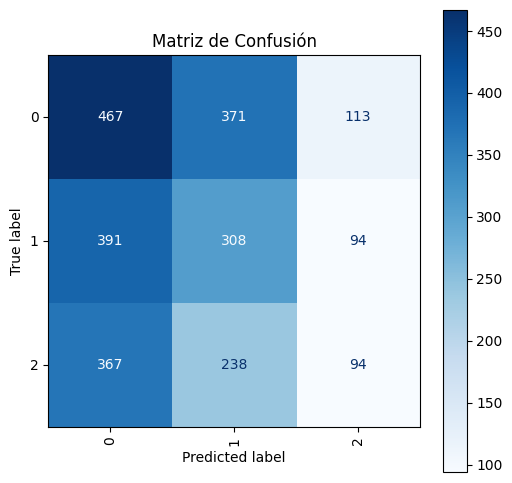

In [23]:
# ➕ 1. Definición del modelo (MLP con 5 capas ocultas de 10 neuronas)
input_dim = len(x_train[0])     # ajusta según tus datos
num_classes = 3
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=(input_dim,)))
for _ in range(5):
    model.add(tf.keras.layers.Dense(10, activation='relu'))
model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

# ➕ 2. Compilación del modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ➕ 3. Entrenamiento: 5 épocas
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)  # ejemplo con split de validación

# ➕ 4. Evaluación final en el conjunto de prueba
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

# ➕ 5. Predicciones y obtención de etiquetas
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Asegurar que y_test esté en formato entero
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# ➕ 6. Métricas y matriz de confusión
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.unique(y_true))
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(include_values=True, cmap='Blues', ax=ax, xticks_rotation='vertical')
plt.title('Matriz de Confusión')
plt.show()


# ENTRENAMIENTO BAJO LSTM

In [24]:
import csv
import tensorflow
tensorflow.config.run_functions_eagerly(True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from tqdm import tqdm
import requests
print(tensorflow.__version__)

2.18.0


In [26]:
import pandas as pd
print('Cargando datos...')
data = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/train.tsv', sep='\t')
data_dev = pd.read_csv('/content/drive/MyDrive/corpusTASS-2020/dev.tsv', sep='\t')


# Diccionario de mapeo de etiquetas
mapeo_etiquetas = {'N': 0, 'NEU': 1, 'P': 2}

# Transformación de la columna "etiqueta"
data['etiqueta_num'] = data['etiqueta'].map(mapeo_etiquetas)
data_dev['etiqueta_num'] = data_dev['etiqueta'].map(mapeo_etiquetas)

x_train, y_train = data['texto'], data['etiqueta_num']
x_test, y_test = data_dev['texto'], data_dev['etiqueta_num']
print("listo")


Cargando datos...
listo


In [27]:
y_train = np.array([y_train[x] for x in range(len(y_train))]);
y_test = np.array([y_test[x] for x in range(len(y_test))]);

In [28]:
y_train = tensorflow.keras.utils.to_categorical(y_train, 3)
y_test = tensorflow.keras.utils.to_categorical(y_test, 3)

In [29]:
x_train[:10]

,texto
0,@morbosaborealis jajajaja... eso es verdad... ...
1,@Adriansoler espero y deseo que el interior te...
2,"comprendo que te molen mis tattoos, pero no te..."
3,"Mi última partida jugada, con Sona support. La..."
4,Tranquilos que con el.dinero de Camacho seguro...
5,"@daniacal aún no, pero si estará jugable en el..."
6,@ragnomuelle Yo a veces hecho de menos mi pelo...
7,A mí nunca me podrán hacer una broma porque no...
8,#feliz septiembre..es bonito retarse..es incre...
9,Este año el Madrid hará triplete y si lo hace ...


In [30]:
vocab_size = 10000
embedding_dim = 64
max_length = 250
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>'

In [31]:
train_articles = data['texto'].tolist()
#train_labels = data['etiqueta_num'].tolist()

validation_articles = data_dev['texto'].tolist()
#validation_labels = data_dev['etiqueta_num'].tolist()

print(len(train_articles))
#print(len(train_labels))
print(len(validation_articles))
#print(len(validation_labels))

4802
2443


## Se crea el Tokenizer

Se expresa de cuál es el número máximo de palabras, el token para palabras que no estén en el vocabulario y que las pase minúsculas para reducir el tamaño del mismo

In [32]:
tokenizer = Tokenizer(num_words = vocab_size, oov_token=oov_tok, lower=True)
tokenizer.fit_on_texts(train_articles)
word_index = tokenizer.word_index
dict(list(word_index.items())[:10])

{'<OOV>': 1,
 'que': 2,
 'de': 3,
 'y': 4,
 'no': 5,
 'a': 6,
 'la': 7,
 'me': 8,
 'el': 9,
 'en': 10}

Se tokeniza el dataset de entrenamiento una vez que se tiene el vocabulario listo.

In [33]:
train_sequences = tokenizer.texts_to_sequences(train_articles)
print(train_sequences[0])

[4563, 177, 45, 11, 123, 147, 5, 47, 103, 4564]


Se aplica padding a secuencias de entrenamiento para que todas tengan la misma longitud. Para este caso particular no hizo falta

In [34]:
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print(len(train_sequences[0]))
print(len(train_padded[0]))

print(len(train_sequences[1]))
print(len(train_padded[1]))

print(len(train_sequences[10]))
print(len(train_padded[10]))

10
250
11
250
21
250


In [35]:
print(train_padded[0])

[4563  177   45   11  123  147    5   47  103 4564    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0 

Se hace lo propio con el dataset de validación

In [36]:
validation_sequences = tokenizer.texts_to_sequences(validation_articles)
validation_padded = pad_sequences(validation_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(len(validation_sequences))
print(validation_padded.shape)

2443
(2443, 250)


NUEVA SECUENCIA: Decodificación de una secuencia tokenizada a texto de nuevo, debido al tokenizer que creado

In [37]:
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_article(text):
    return ' '.join([reverse_word_index.get(i, '?') for i in text])
print(decode_article(train_padded[0]))
print('---')
print(train_articles[0])

morbosaborealis jajajaja eso es verdad aquí no hay uno cuerdo ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ?
---
@morbosaborealis jajajaja... eso es verdad... aquí no hay uno cuerdo 


## Modelo de red neuronal

- Utilizaremos la `Sequential` API de Keras
- Creamos una primera capa de `Embedding`que tiene por tamaño `vocab_size`x `embedding_dim`
- Despues añadimos nuestra capa de recurrencia. En este caso será una `LSTM` bidireccional (aprende de izquerida a derecha y de derecha a izquierda)
- Conectamos la salida de esa capa a una capa `Dense`.
- Por último, conectamos todo a una capa `Dense`con función de activación `sigmoid`ya que nuestro problema de clasificación es binario.

In [38]:
model = tensorflow.keras.Sequential([
    tensorflow.keras.layers.Embedding(vocab_size, embedding_dim),
    tensorflow.keras.layers.Dropout(0.2),
    tensorflow.keras.layers.Bidirectional(tensorflow.keras.layers.LSTM(embedding_dim)),
    tensorflow.keras.layers.Dense(embedding_dim, activation='relu'),
    tensorflow.keras.layers.Dropout(0.2),
    tensorflow.keras.layers.Dense(3, activation='softmax')
])

In [39]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [40]:
num_epochs = 3
history = model.fit(train_padded, y_train, epochs=num_epochs, validation_data=(validation_padded, y_test), verbose=2)

Epoch 1/3


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


151/151 - 810s - 5s/step - accuracy: 0.4296 - loss: 1.0623 - val_accuracy: 0.4834 - val_loss: 1.0123
Epoch 2/3
151/151 - 852s - 6s/step - accuracy: 0.6197 - loss: 0.8392 - val_accuracy: 0.5227 - val_loss: 0.9827
Epoch 3/3
151/151 - 782s - 5s/step - accuracy: 0.7661 - loss: 0.5777 - val_accuracy: 0.5366 - val_loss: 1.0898


## Se visualiza los resultados

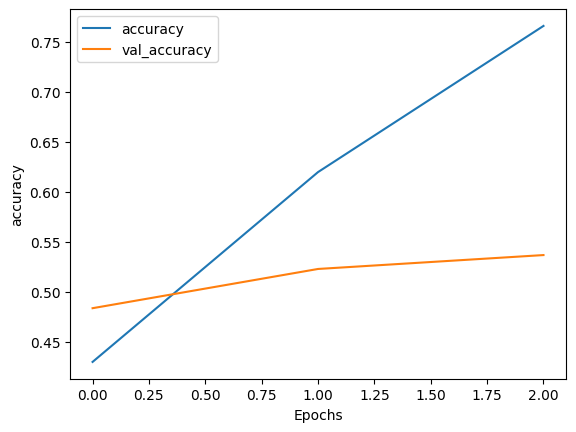

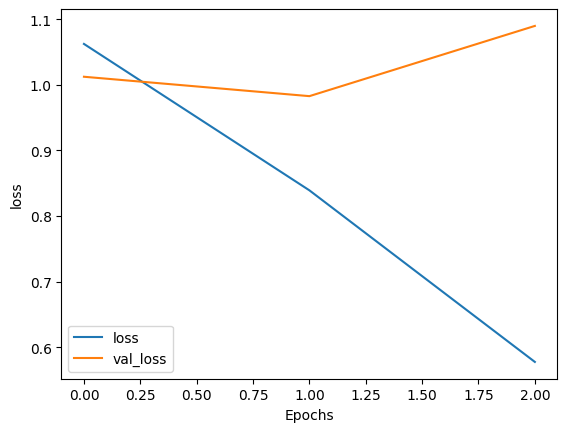

In [41]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

## Modelo prueba

In [42]:
validation_articles[50], y_test[50]

('Ojalá alguien llamandome bonito o precioso  sad', array([1., 0., 0.]))

In [43]:
def get_class(pred):

  return np.where(pred[0] == max(pred[0]))[0][0]

In [44]:
txt = ['''
Que hermoso día para aprender sobre procesamiento de lenguaje natural !! Muy feliz de estar aqui :-) bien, bueno
''']
seq = tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
print(pred)

posiblesSalidas = dict();
posiblesSalidas[2] = "Parece un texto negativo "
posiblesSalidas[1] = "Parece un texto neutro "
posiblesSalidas[0] = "Parece un texto positivo "

print(posiblesSalidas[get_class(pred)]);

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
[[0.17659952 0.29015553 0.53324497]]
Parece un texto negativo 


# ENTRENAMIENTO DE MODELO RNN y GRU

In [45]:
import tensorflow as tf

In [47]:
sequence_length = 100  # segun la necesidad de secuencia
model_rnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=sequence_length),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(embedding_dim)),
    tf.keras.layers.Dense(embedding_dim, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
model_rnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [49]:
num_epochs = 3
history = model_rnn.fit(train_padded, y_train, epochs=num_epochs, validation_data=(validation_padded, y_test), verbose=2)

Epoch 1/3
151/151 - 495s - 3s/step - accuracy: 0.3757 - loss: 1.1009 - val_accuracy: 0.3893 - val_loss: 1.0907
Epoch 2/3
151/151 - 532s - 4s/step - accuracy: 0.3713 - loss: 1.1074 - val_accuracy: 0.3893 - val_loss: 1.1000
Epoch 3/3
151/151 - 558s - 4s/step - accuracy: 0.3894 - loss: 1.0899 - val_accuracy: 0.3893 - val_loss: 1.0872


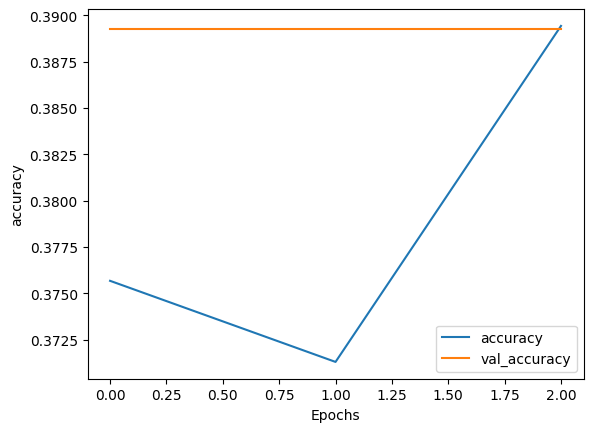

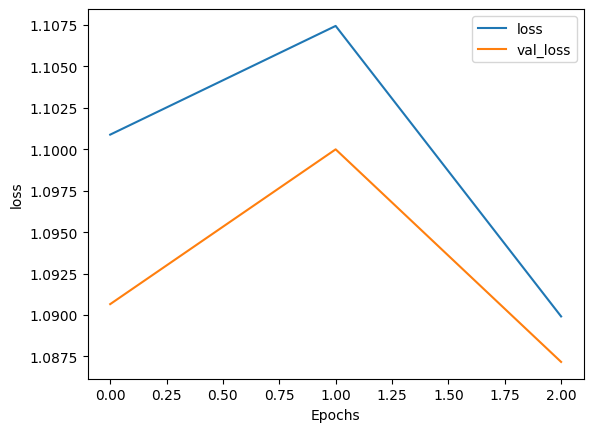

In [50]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [51]:
import tensorflow as tf

In [52]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=sequence_length),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(embedding_dim)),
    tf.keras.layers.Dense(embedding_dim, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(3, activation='softmax')
])


In [53]:
model_gru.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [54]:
num_epochs = 3
history = model_gru.fit(train_padded, y_train, epochs=num_epochs, validation_data=(validation_padded, y_test), verbose=2)

Epoch 1/3
151/151 - 1352s - 9s/step - accuracy: 0.4265 - loss: 1.0653 - val_accuracy: 0.4740 - val_loss: 1.0302
Epoch 2/3
151/151 - 1388s - 9s/step - accuracy: 0.6106 - loss: 0.8565 - val_accuracy: 0.4965 - val_loss: 1.0195
Epoch 3/3
151/151 - 1353s - 9s/step - accuracy: 0.7813 - loss: 0.5518 - val_accuracy: 0.5194 - val_loss: 1.1242


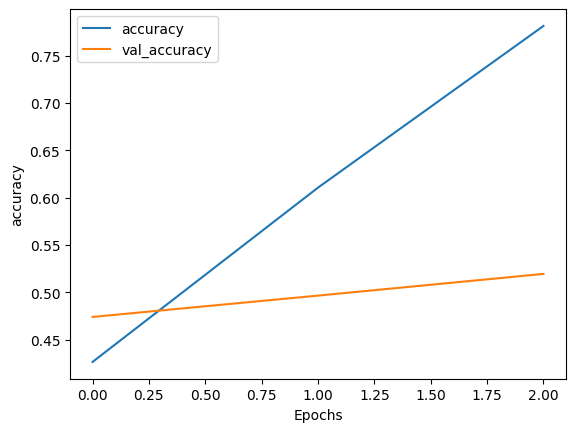

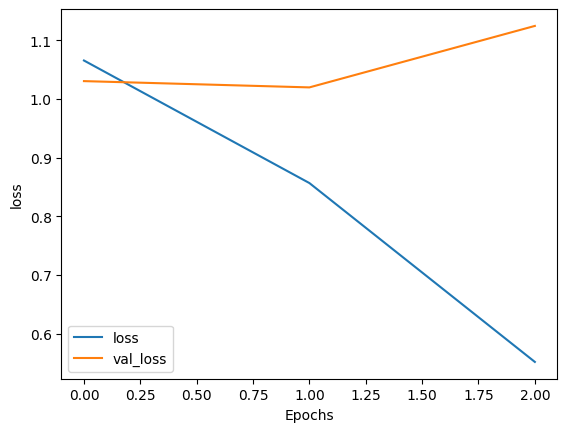

In [55]:
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")